# 03 — towers

**What this notebook does.** Builds the carrier mobile-tower layer from the ACMA licence
register: one row per **on-the-ground tower site** that has at least one mobile-carrier
transmitter operating in a handset band (700 / 850 / 900 / 1800 / 2100 MHz). Co-located
sites (a shared compound where two or three carriers each hold a separate `SITE_ID` within
100 m) are merged into one row so a nearby village is not later counted as being near
"three towers".

**Two things this table is NOT:**
- **Not a coverage map.** A licence is *permission to transmit*, not proof the site is
  switched on, nor a signal-strength claim. Distances measured from these points later are
  straight-line triage only.
- **`spectrum_depth_khz` is a relative capacity indicator, not a speed.** It is the total
  distinct licensed channel width across a site's handset-band transmitters (deduplicated
  on `carrier` × `frequency` × `bandwidth`, so repeated sectors are not double-counted).
  More spectrum usually means more capacity — it is not megabits and not coverage.

**`carriers` vs `networks`.** `carriers` is the raw list of licensee brands at the site.
`networks` collapses the brands that are the same physical network — **Vodafone, Hutchison
and TPG → `TPG`** (the merged TPG Telecom / VHA network); Telstra, Optus, Pivotel, Dense Air
unchanged. `n_networks` is what nb 06 uses to judge redundancy (two brands of one network is
not two networks).

**What it reads** (raw / external only):

| dataframe | file | columns used |
|---|---|---|
| `acma_sites_df` | `external/acma_rrl/site.csv` | `SITE_ID, LATITUDE, LONGITUDE, NAME, STATE` |
| `acma_licences_df` | `external/acma_rrl/licence.csv` | `LICENCE_NO, CLIENT_NO, LICENCE_CATEGORY_NAME` |
| `acma_clients_df` | `external/acma_rrl/client.csv` | `CLIENT_NO, LICENCEE` |
| `acma_devices_nt_df` | `external/acma_rrl/device_details.csv` | `SITE_ID, LICENCE_NO, DEVICE_TYPE, FREQUENCY, BANDWIDTH` — **NT sites only, read in chunks** |

**What it writes** (`data/processed/`):

| file | one row is | key |
|---|---|---|
| `towers.csv` | one tower site (co-located sites merged) | `site_id` |
| `towers.geojson` | same, as points (EPSG:4326) | `site_id` |

**Decisions carried in** (`PROJECT_CONTEXT.md` §11, from 00b):
- Tower = carrier transmitter (`DEVICE_TYPE == 'T'`) with `FREQUENCY` (Hz) in a handset band.
  `BANDWIDTH` is Hz → `/1000` for kHz.
- `is_planning_site` (name contains Planning / Nominal / Proposed) flags register entries that
  are not built towers — **kept, not dropped**, so nb 06 can decide whether to exclude them.
- **Co-location clustering happens here**, not in nb 06: handset towers within **100 m**
  collapse to one row; `spectrum_depth_khz` is recomputed on the merged set with duplicate
  channels removed.
- The old 16-category `LICENCE_CATEGORY_NAME` method ("acma 458") is reproduced for
  comparison only.

In [1]:
# Every import for the whole notebook lives in this cell.
%matplotlib inline
import os
from pathlib import Path

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.sparse.csgraph import connected_components
from scipy.sparse import coo_matrix

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

In [2]:
# Every file the notebook needs is read here. device_details is streamed in chunks and
# filtered to NT sites as it is read — the raw read still happens in this cell.

ACMA_DIR    = "data/external/acma_rrl"
SITE_CSV    = f"{ACMA_DIR}/site.csv"
LICENCE_CSV = f"{ACMA_DIR}/licence.csv"
CLIENT_CSV  = f"{ACMA_DIR}/client.csv"
DEVICE_CSV  = f"{ACMA_DIR}/device_details.csv"

acma_sites_df    = pd.read_csv(SITE_CSV, dtype=str)
acma_licences_df = pd.read_csv(LICENCE_CSV, dtype=str,
                               usecols=["LICENCE_NO", "CLIENT_NO", "LICENCE_CATEGORY_NAME"])
acma_clients_df  = pd.read_csv(CLIENT_CSV, dtype=str, usecols=["CLIENT_NO", "LICENCEE"])

_nt_site_ids = set(acma_sites_df.loc[acma_sites_df["STATE"] == "NT", "SITE_ID"])
_device_cols = ["SITE_ID", "LICENCE_NO", "DEVICE_TYPE", "FREQUENCY", "BANDWIDTH"]
_chunks = []
for _chunk in pd.read_csv(DEVICE_CSV, dtype=str, usecols=_device_cols, chunksize=200_000):
    _chunks.append(_chunk[_chunk["SITE_ID"].isin(_nt_site_ids)])
acma_devices_nt_df = pd.concat(_chunks, ignore_index=True)

OUT_DIR = Path("data/processed"); OUT_DIR.mkdir(parents=True, exist_ok=True)
EDA_PLOT_DIR = Path("docs/eda"); EDA_PLOT_DIR.mkdir(parents=True, exist_ok=True)
eda_figures = {}

print(f"acma_sites_df      : {len(acma_sites_df)} rows ({len(_nt_site_ids)} NT)")
print(f"acma_licences_df   : {len(acma_licences_df)} rows")
print(f"acma_clients_df    : {len(acma_clients_df)} rows")
print(f"acma_devices_nt_df : {len(acma_devices_nt_df)} rows (NT sites only)")

acma_sites_df      : 129492 rows (3771 NT)
acma_licences_df   : 164205 rows
acma_clients_df    : 14332 rows
acma_devices_nt_df : 26767 rows (NT sites only)


## 1. NT sites with a usable coordinate

In [3]:
acma_sites_nt_df = acma_sites_df[acma_sites_df["STATE"] == "NT"].copy()
acma_sites_nt_df["latitude"]  = pd.to_numeric(acma_sites_nt_df["LATITUDE"], errors="coerce")
acma_sites_nt_df["longitude"] = pd.to_numeric(acma_sites_nt_df["LONGITUDE"], errors="coerce")
acma_sites_nt_df = acma_sites_nt_df.dropna(subset=["latitude", "longitude"])
acma_sites_nt_df = acma_sites_nt_df[["SITE_ID", "NAME", "latitude", "longitude"]].rename(
    columns={"SITE_ID": "site_id", "NAME": "name"})
print(f"{len(acma_sites_nt_df)} NT sites with coordinates")
assert acma_sites_nt_df["site_id"].is_unique, "site.csv has a duplicate NT SITE_ID"

3771 NT sites with coordinates


## 2. Which licences are held by a mobile carrier?

`licence.CLIENT_NO → client.CLIENT_NO` gives the licensee name; a name containing one of the
known operator strings marks it as a carrier. `CARRIER_NAME` maps the matched fragment to a
tidy brand name (TPG stays upper-case); `NETWORK_OF` then folds the brands that share one
physical network.

In [4]:
# licensee-name fragment -> tidy brand
CARRIER_NAME = {
    "TELSTRA": "Telstra", "OPTUS": "Optus", "VODAFONE": "Vodafone", "TPG": "TPG",
    "HUTCHISON": "Hutchison", "PIVOTEL": "Pivotel", "DENSE AIR": "Dense Air",
}
# brand -> physical network (Vodafone / Hutchison / TPG are one network post-merger)
NETWORK_OF = {
    "Telstra": "Telstra", "Optus": "Optus",
    "Vodafone": "TPG", "Hutchison": "TPG", "TPG": "TPG",
    "Pivotel": "Pivotel", "Dense Air": "Dense Air",
}

def carrier_of(licensee):
    text = (licensee or "").upper()
    for fragment, brand in CARRIER_NAME.items():
        if fragment in text:
            return brand
    return None

def networks_from_carriers(carrier_tokens):
    # ['Vodafone','TPG','Telstra'] -> 'TPG;Telstra'  (sorted, de-duped physical networks)
    return ";".join(sorted({NETWORK_OF[c] for c in carrier_tokens}))

licence_client_df = acma_licences_df.merge(acma_clients_df, on="CLIENT_NO", how="left")
licence_client_df["carrier"] = licence_client_df["LICENCEE"].map(carrier_of)
carrier_licence_df = licence_client_df[licence_client_df["carrier"].notna()]
print(f"{len(carrier_licence_df)} carrier-held licences (all AU)")
print(carrier_licence_df["carrier"].value_counts())

17472 carrier-held licences (all AU)
carrier
Telstra      9819
Optus        6869
Vodafone      716
TPG            34
Pivotel        31
Hutchison       2
Dense Air       1
Name: count, dtype: int64


## 3. Carrier transmitters on NT sites, tagged by handset band

Join the NT device rows to the carrier licences, keep **transmitters** (`DEVICE_TYPE == 'T'`
— confirmed in 00b as the only transmit code), and label each by the handset band its
`FREQUENCY` (Hz) falls in. `handset_band` is a boolean so a non-handset carrier transmitter
(backhaul, 2.5 GHz capacity, mmWave) stays visible in the funnel.

The 850 window ends at 890 MHz and the 900 window starts at 890 MHz — no overlap.

In [5]:
# handset-band frequency windows, Hz. Generous but non-overlapping. NOT a coverage claim.
HANDSET_BAND_HZ = {
    "700":  (703e6,  803e6),
    "850":  (824e6,  890e6),
    "900":  (890e6,  960e6),
    "1800": (1710e6, 1880e6),
    "2100": (1920e6, 2170e6),
}

nt_devices_with_carrier_df = acma_devices_nt_df.merge(
    licence_client_df[["LICENCE_NO", "carrier", "LICENCE_CATEGORY_NAME"]], on="LICENCE_NO", how="left")
nt_devices_with_carrier_df["freq_hz"]  = pd.to_numeric(nt_devices_with_carrier_df["FREQUENCY"], errors="coerce")
nt_devices_with_carrier_df["bw_hz"]    = pd.to_numeric(nt_devices_with_carrier_df["BANDWIDTH"], errors="coerce")

def band_label(f):
    if pd.isna(f):
        return None
    for name, (lo, hi) in HANDSET_BAND_HZ.items():
        if lo <= f <= hi:
            return name
    return "other"

nt_devices_with_carrier_df["band"] = nt_devices_with_carrier_df["freq_hz"].map(band_label)
nt_devices_with_carrier_df["handset_band"] = nt_devices_with_carrier_df["band"].isin(HANDSET_BAND_HZ)

carrier_tx_df = nt_devices_with_carrier_df[
    (nt_devices_with_carrier_df["DEVICE_TYPE"] == "T") & nt_devices_with_carrier_df["carrier"].notna()].copy()
handset_tx_df = carrier_tx_df[carrier_tx_df["handset_band"]].copy()

print(f"carrier transmitters on NT sites: {len(carrier_tx_df)}  |  in a handset band: {len(handset_tx_df)}")
print("\ncarrier transmitters by band:")
print(carrier_tx_df["band"].value_counts(dropna=False))

carrier transmitters on NT sites: 7387  |  in a handset band: 5485

carrier transmitters by band:
band
other    1902
850      1424
700      1399
2100     1270
1800     1037
900       355
Name: count, dtype: int64


### FREQUENCY spectrum with the handset-band windows shaded, and carrier × band

carrier x band (transmitter counts):
band      1800  2100  700   850  900  other
carrier                                    
Optus      253   321  344     0  355    440
Pivotel      2     0    0     0    0      0
TPG        259     0  176     0    0      0
Telstra    253   400  809  1117    0   1448
Vodafone   270   549   70   307    0     14


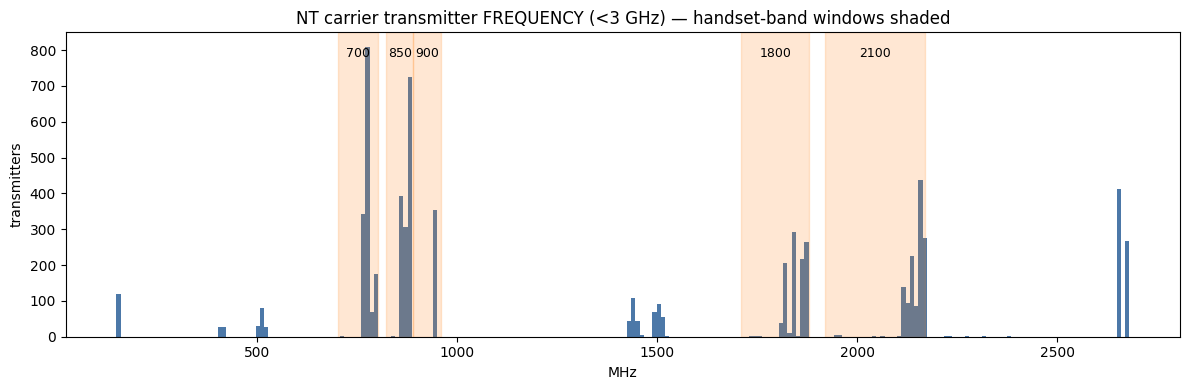

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
f_mhz = (carrier_tx_df["freq_hz"].dropna() / 1e6)
ax.hist(f_mhz[f_mhz < 3000], bins=240, color="#4c78a8")
for name, (lo, hi) in HANDSET_BAND_HZ.items():
    ax.axvspan(lo / 1e6, hi / 1e6, color="#ff7f0e", alpha=0.18)
    ax.text((lo + hi) / 2e6, ax.get_ylim()[1] * 0.92, name, ha="center", fontsize=9)
ax.set_title("NT carrier transmitter FREQUENCY (<3 GHz) — handset-band windows shaded")
ax.set_xlabel("MHz"); ax.set_ylabel("transmitters")
fig.tight_layout()
eda_figures["03_towers_frequency_bands"] = fig

print("carrier x band (transmitter counts):")
print(pd.crosstab(carrier_tx_df["carrier"], carrier_tx_df["band"]).to_string())

### Pintpoint: what frequencies are Pivotel's transmitters on?

In [7]:
piv = carrier_tx_df[carrier_tx_df["carrier"] == "Pivotel"]
print(f"Pivotel carrier transmitters on NT sites: {len(piv)}  across {piv['SITE_ID'].nunique()} site(s)")
print(piv.assign(freq_MHz=(piv["freq_hz"] / 1e6).round(3),
                 bw_kHz=(piv["bw_hz"] / 1e3).round(1))
        [["SITE_ID", "freq_MHz", "bw_kHz", "band", "LICENCE_CATEGORY_NAME"]]
        .sort_values("freq_MHz").to_string(index=False))
print("\n-> note which of these land inside a handset-band window (band != 'other').")

Pivotel carrier transmitters on NT sites: 2  across 2 site(s)
 SITE_ID  freq_MHz  bw_kHz band LICENCE_CATEGORY_NAME
10045401    1875.0 10000.0 1800          PMTS Class B
10045402    1875.0 10000.0 1800          PMTS Class B

-> note which of these land inside a handset-band window (band != 'other').


### Validate: the selection funnel

NT sites (with coords)                       3771
NT device rows (chunked)                    26767
... transmitters (DEVICE_TYPE == 'T')       13748
... held by a carrier                        7387
... in a handset band                        5485
distinct NT sites with a handset-band tx      461


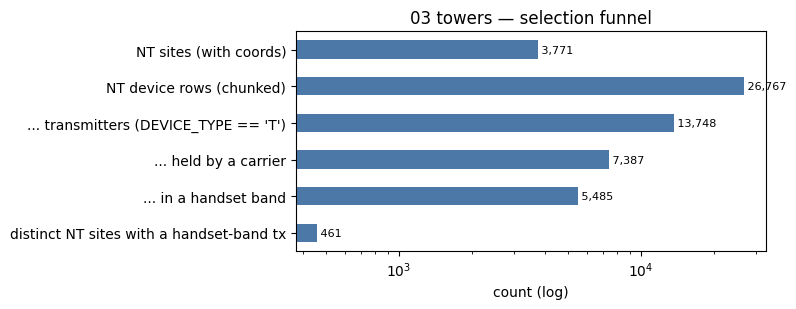

In [8]:
funnel = pd.Series({
    "NT sites (with coords)":                     len(acma_sites_nt_df),
    "NT device rows (chunked)":                   len(acma_devices_nt_df),
    "... transmitters (DEVICE_TYPE == 'T')":      int((acma_devices_nt_df["DEVICE_TYPE"] == "T").sum()),
    "... held by a carrier":                      len(carrier_tx_df),
    "... in a handset band":                      len(handset_tx_df),
    "distinct NT sites with a handset-band tx":   handset_tx_df["SITE_ID"].nunique(),
})
print(funnel.to_string())

fig, ax = plt.subplots(figsize=(8, 3.2))
funnel.iloc[::-1].plot.barh(ax=ax, color="#4c78a8")
for i, v in enumerate(funnel.iloc[::-1]):
    ax.text(v, i, f" {v:,}", va="center", fontsize=8)
ax.set_title("03 towers — selection funnel")
ax.set_xscale("log"); ax.set_xlabel("count (log)")
fig.tight_layout()
eda_figures["03_towers_funnel"] = fig

## 4. One row per site (before co-location clustering)

Aggregates are over the site's **handset-band** carrier transmitters. `spectrum_depth_khz_raw`
here is the naive sum of every transmitter's `BANDWIDTH` (repeated sectors included) — it is
recomputed with duplicates removed after clustering in step 5.

In [9]:
site_name_lookup = acma_sites_nt_df.set_index("site_id")[["name", "latitude", "longitude"]]

handset_tx_grouped_by_site = handset_tx_df.groupby("SITE_ID")
towers_per_site_df = pd.DataFrame({
    "carriers":              handset_tx_grouped_by_site["carrier"].agg(lambda s: ";".join(sorted(set(s)))),
    "n_carriers":            handset_tx_grouped_by_site["carrier"].nunique(),
    "n_transmitters":        handset_tx_grouped_by_site.size(),
    "bands":                 handset_tx_grouped_by_site["band"].agg(lambda s: ";".join(sorted(set(s)))),
    "spectrum_depth_khz_raw": (handset_tx_grouped_by_site["bw_hz"].sum() / 1000).round(1),
})
towers_per_site_df["networks"]   = towers_per_site_df["carriers"].apply(
    lambda s: networks_from_carriers(s.split(";")))
towers_per_site_df["n_networks"] = towers_per_site_df["networks"].apply(lambda s: len(s.split(";")))
towers_per_site_df["is_pivotel"] = towers_per_site_df["carriers"].str.contains("Pivotel")
towers_per_site_df = towers_per_site_df.join(site_name_lookup, how="left").reset_index().rename(
    columns={"SITE_ID": "site_id"})

# register entries that are not built towers — a Planning / Nominal / Proposed placeholder in
# the site NAME. Flagged, never dropped; nb 06 chooses whether to exclude them from distance.
PLANNING_NAME_RE = r"planning|nominal|proposed"
towers_per_site_df["is_planning_site"] = towers_per_site_df["name"].str.contains(
    PLANNING_NAME_RE, case=False, na=False)

assert towers_per_site_df["latitude"].notna().all(), "a handset-band site has no coordinate"
print(f"{len(towers_per_site_df)} NT sites with >=1 carrier handset-band transmitter")
print(f"  of which is_planning_site (name has Planning/Nominal/Proposed): "
      f"{int(towers_per_site_df['is_planning_site'].sum())}")
if towers_per_site_df["is_planning_site"].any():
    print(towers_per_site_df.loc[towers_per_site_df["is_planning_site"],
                                 ["site_id", "name", "carriers"]].to_string(index=False))
print("\nby brand (a site can have several):")
for brand in CARRIER_NAME.values():
    n = int(towers_per_site_df["carriers"].str.contains(brand).sum())
    if n:
        print(f"  {brand:10s} {n}")
towers_per_site_df.head()

461 NT sites with >=1 carrier handset-band transmitter
  of which is_planning_site (name has Planning/Nominal/Proposed): 1
site_id                                      name carriers
   1230 Nominal Planning Site Blake Street DARWIN  Telstra

by brand (a site can have several):
  Telstra    328
  Optus      162
  Vodafone   57
  TPG        75
  Pivotel    2


,site_id,carriers,n_carriers,n_transmitters,bands,spectrum_depth_khz_raw,networks,n_networks,is_pivotel,name,latitude,longitude,is_planning_site
0,10000796,Telstra,1,20,1800;2100;700;850,275000.0,Telstra,1,False,Telstra Site Anzac Oval Wills Terrace Alice Sp...,-23.696169,133.884366,False
1,10000987,Telstra,1,6,700;850,104700.0,Telstra,1,False,Dead Bullock Soak Tanami,-20.533340,129.936940,False
2,10002390,Telstra,1,6,700;850,104700.0,Telstra,1,False,Defence Site Lattice Tower Off Tanami Road Bur...,-23.523950,133.680870,False
3,10002545,Telstra,1,2,700;850,34900.0,Telstra,1,False,Telstra Radio Site Lot 41 Yarralin,-16.448140,130.884212,False
4,10002679,Optus;TPG;Telstra,3,62,1800;2100;700;850;900,875000.0,Optus;TPG;Telstra,3,False,24 Grevillea Drive SADADEEN,-23.699840,133.894590,False


### Validate: old 16-category method vs this frequency method — what changed, both ways

In [10]:
OLD_16_CATEGORIES = {
    "700 MHz Band", "800 MHz Band", "850/900 MHz Band", "900 MHz Band", "1800 MHz Band",
    "1900 MHz Band", "2 GHz Band", "2.1 GHz Band", "2.3 GHz Band", "2.5 GHz Band",
    "3.4 GHz Band", "3.6 GHz Band", "26 GHz Band", "28 GHz Band", "PMTS Class B", "AWL - Standard",
}
old_hit_df = nt_devices_with_carrier_df[
    nt_devices_with_carrier_df["carrier"].notna()
    & nt_devices_with_carrier_df["LICENCE_CATEGORY_NAME"].isin(OLD_16_CATEGORIES)]
old_ids = set(old_hit_df["SITE_ID"])
new_ids = set(towers_per_site_df["site_id"])

print(f"OLD 16-category method : {len(old_ids)} sites   (previous build reported 'acma 458')")
print(f"NEW frequency method   : {len(new_ids)} sites")
print(f"kept by both : {len(old_ids & new_ids)}   only-old (dropped): {len(old_ids - new_ids)}   "
      f"only-new (added): {len(new_ids - old_ids)}")

print("\nonly-OLD sites, by the 16-category that had selected them:")
print(old_hit_df[old_hit_df["SITE_ID"].isin(old_ids - new_ids)]
      .groupby("LICENCE_CATEGORY_NAME")["SITE_ID"].nunique().sort_values(ascending=False))

only_new_devices = nt_devices_with_carrier_df[
    (nt_devices_with_carrier_df["SITE_ID"].isin(new_ids - old_ids))
    & (nt_devices_with_carrier_df["DEVICE_TYPE"] == "T")
    & nt_devices_with_carrier_df["handset_band"]]
print("\nonly-NEW sites, by the LICENCE_CATEGORY_NAME of their handset-band transmitter(s):")
print(only_new_devices.groupby("LICENCE_CATEGORY_NAME")["SITE_ID"].nunique().sort_values(ascending=False))
print("\n-> only-old = capacity/mmWave-only sites (2.5 GHz etc.) with no handset transmitter; "
      "only-new = handset transmitters filed under a category the fixed 16-list didn't include.")

OLD 16-category method : 458 sites   (previous build reported 'acma 458')
NEW frequency method   : 461 sites
kept by both : 453   only-old (dropped): 5   only-new (added): 8

only-OLD sites, by the 16-category that had selected them:
LICENCE_CATEGORY_NAME
2.5 GHz Band    5
Name: SITE_ID, dtype: int64

only-NEW sites, by the LICENCE_CATEGORY_NAME of their handset-band transmitter(s):
LICENCE_CATEGORY_NAME
Point to Point    8
Name: SITE_ID, dtype: int64

-> only-old = capacity/mmWave-only sites (2.5 GHz etc.) with no handset transmitter; only-new = handset transmitters filed under a category the fixed 16-list didn't include.


## 5. Merge co-located sites (within 100 m)

00b found 151 of these sites have *some* other ACMA site within 100 m; here we only merge a
handset tower with **another handset tower**. Connected components on handset-tower pairs
within **100 m** (EPSG:3577 metres). Each cluster collapses to one row:

- `carriers` / `bands` unioned; `networks` recomputed from the union
- `n_transmitters` summed
- **`spectrum_depth_khz` recomputed** on the cluster's transmitters with duplicate
  `carrier × frequency × bandwidth` rows removed (repeated sectors, and the same channel
  filed by two co-located `SITE_ID`s, are counted once)
- `is_pivotel` / `is_planning_site` = any member true
- `n_colocated` = sites merged; representative `site_id` / coordinate = the member with the
  most transmitters

In [11]:
CLUSTER_M = 100  # a shared compound; not a coverage radius

pts_3577 = gpd.GeoSeries(
    gpd.points_from_xy(towers_per_site_df["longitude"], towers_per_site_df["latitude"]),
    crs="EPSG:4326").to_crs("EPSG:3577")
xy = np.c_[pts_3577.x.values, pts_3577.y.values]

pairs = cKDTree(xy).query_pairs(r=CLUSTER_M, output_type="ndarray")
n = len(xy)
adj = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])), shape=(n, n)) if len(pairs) \
      else coo_matrix((n, n))
n_clusters, cluster_label = connected_components(adj, directed=False)
towers_per_site_df["cluster"] = cluster_label

# --- spectrum depth, recomputed per cluster with duplicate channels removed ---
handset_tx_with_cluster_df = handset_tx_df.merge(
    towers_per_site_df[["site_id", "cluster"]], left_on="SITE_ID", right_on="site_id", how="left")
cluster_spectrum_df = (handset_tx_with_cluster_df
    .drop_duplicates(subset=["cluster", "carrier", "freq_hz", "bw_hz"])
    .groupby("cluster")["bw_hz"].sum().div(1000).round(1).rename("spectrum_depth_khz"))

def union_tokens(series, sep=";"):
    toks = set()
    for v in series.dropna():
        toks.update(t for t in str(v).split(sep) if t)
    return sep.join(sorted(toks))

cluster_agg_df = towers_per_site_df.groupby("cluster").agg(
    n_colocated=("site_id", "size"),
    colocated_site_ids=("site_id", lambda s: ";".join(sorted(s))),
    carriers=("carriers", union_tokens),
    bands=("bands", union_tokens),
    n_transmitters=("n_transmitters", "sum"),
    is_pivotel=("is_pivotel", "any"),
    is_planning_site=("is_planning_site", "any"),
)
cluster_agg_df["n_carriers"] = cluster_agg_df["carriers"].apply(lambda s: len([x for x in s.split(";") if x]))
cluster_agg_df["networks"]   = cluster_agg_df["carriers"].apply(lambda s: networks_from_carriers(s.split(";")))
cluster_agg_df["n_networks"] = cluster_agg_df["networks"].apply(lambda s: len(s.split(";")))
cluster_agg_df = cluster_agg_df.join(cluster_spectrum_df)

cluster_representative_df = (towers_per_site_df
    .sort_values(["cluster", "n_transmitters", "site_id"], ascending=[True, False, True])
    .groupby("cluster").first()[["site_id", "name", "latitude", "longitude"]])

towers_clustered_df = cluster_agg_df.join(cluster_representative_df).reset_index(drop=True)
print(f"{n} sites -> {n_clusters} clusters")

461 sites -> 431 clusters


### Validate the clustering: totals, the 3 named sites before/after, the multi-site clusters

rows before clustering : 461
rows after clustering  : 431
clusters merging >1 site: 30  (60 handset towers collapse in; largest merges 2)
spectrum_depth_khz: deduped <= raw sum for every cluster  (OK); total raw 79,254,330 kHz -> deduped 26,680,480 kHz
n_transmitters total preserved: True

before / after for three named sites (naive per-sector sum -> deduped distinct channels;
before/after cover every pre-cluster site in the cluster(s) the named site belongs to):
  Dead Bullock Soak  2 pre-cluster site(s) -> 2 tower row(s)  [carriers Telstra]
      before  spectrum    114,700 kHz   n_tx   8
      after   spectrum     44,900 kHz   n_tx   8
  Anzac Oval         2 pre-cluster site(s) -> 2 tower row(s)  [carriers Telstra]
      before  spectrum    344,800 kHz   n_tx  24
      after   spectrum    104,900 kHz   n_tx  24
  Calistermon        2 pre-cluster site(s) -> 1 tower row(s)  [carriers Optus;TPG;Telstra;Vodafone]
      before  spectrum    846,990 kHz   n_tx  69
      after   spectrum   

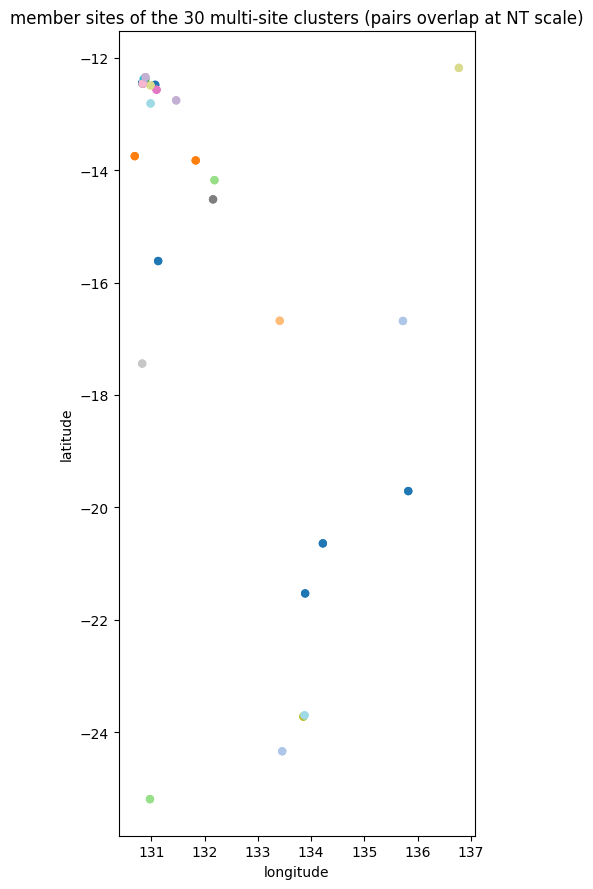

In [12]:
n_merged_rows  = int((towers_clustered_df["n_colocated"] > 1).sum())
n_sites_merged = int(towers_clustered_df.loc[towers_clustered_df["n_colocated"] > 1, "n_colocated"].sum())
print(f"rows before clustering : {len(towers_per_site_df)}")
print(f"rows after clustering  : {len(towers_clustered_df)}")
print(f"clusters merging >1 site: {n_merged_rows}  ({n_sites_merged} handset towers collapse in; "
      f"largest merges {towers_clustered_df['n_colocated'].max()})")

# spectrum: the deduped cluster value must be <= the naive sum of its members' raw values
raw_sum_by_cluster = towers_per_site_df.groupby("cluster")["spectrum_depth_khz_raw"].sum()
deduped_by_cluster = cluster_spectrum_df.reindex(raw_sum_by_cluster.index).fillna(0)
assert (deduped_by_cluster <= raw_sum_by_cluster + 1e-6).all(), "deduped spectrum exceeds the raw sum"
print(f"spectrum_depth_khz: deduped <= raw sum for every cluster  (OK); "
      f"total raw {raw_sum_by_cluster.sum():,.0f} kHz -> deduped {deduped_by_cluster.sum():,.0f} kHz")
print(f"n_transmitters total preserved: "
      f"{towers_per_site_df['n_transmitters'].sum() == towers_clustered_df['n_transmitters'].sum()}")

print("\nbefore / after for three named sites (naive per-sector sum -> deduped distinct channels;")
print("before/after cover every pre-cluster site in the cluster(s) the named site belongs to):")
for needle in ("Dead Bullock Soak", "Anzac Oval", "Calistermon"):
    named = towers_per_site_df[towers_per_site_df["name"].str.contains(needle, case=False, na=False)]
    member_clusters = set(named["cluster"])
    before_sites = towers_per_site_df[towers_per_site_df["cluster"].isin(member_clusters)]
    after_rows   = towers_clustered_df[towers_clustered_df["colocated_site_ids"].apply(
        lambda s: bool(set(before_sites["site_id"]) & set(s.split(";"))))]
    after_carriers = ";".join(sorted(set(";".join(after_rows["carriers"]).split(";"))))
    print(f"  {needle:18s} {len(before_sites)} pre-cluster site(s) -> {len(after_rows)} tower row(s)  "
          f"[carriers {after_carriers}]")
    print(f"      before  spectrum {before_sites['spectrum_depth_khz_raw'].sum():>10,.0f} kHz   "
          f"n_tx {int(before_sites['n_transmitters'].sum()):>3}")
    print(f"      after   spectrum {after_rows['spectrum_depth_khz'].sum():>10,.0f} kHz   "
          f"n_tx {int(after_rows['n_transmitters'].sum()):>3}")

_cluster_sizes = towers_per_site_df["cluster"].value_counts()
_multi_ids = set(_cluster_sizes[_cluster_sizes > 1].index)
multi_site_cluster_members_df = towers_per_site_df[towers_per_site_df["cluster"].isin(_multi_ids)]
_m = gpd.GeoDataFrame(multi_site_cluster_members_df,
                      geometry=gpd.points_from_xy(multi_site_cluster_members_df["longitude"],
                                                  multi_site_cluster_members_df["latitude"]),
                      crs="EPSG:4326")
fig, ax = plt.subplots(figsize=(7.5, 9))
_m.plot(ax=ax, column="cluster", cmap="tab20", markersize=25, legend=False)
ax.set_title(f"member sites of the {n_merged_rows} multi-site clusters (pairs overlap at NT scale)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["03_towers_colocation_clusters"] = fig

## 6. Assemble `towers.csv` — explicit column list

In [13]:
TOWER_COLUMNS = [
    "site_id", "name", "latitude", "longitude",
    "carriers", "n_carriers", "networks", "n_networks", "n_transmitters", "bands",
    "spectrum_depth_khz",
    "is_pivotel", "is_planning_site", "n_colocated", "colocated_site_ids",
]
towers_out_df = (towers_clustered_df[TOWER_COLUMNS]
                 .sort_values("site_id").reset_index(drop=True))
towers_out_df["n_transmitters"] = towers_out_df["n_transmitters"].astype(int)

assert list(towers_out_df.columns) == TOWER_COLUMNS, "column set / order changed"
assert towers_out_df["site_id"].is_unique, "site_id not unique after clustering"
assert (towers_out_df["n_carriers"] >= 1).all() and (towers_out_df["n_transmitters"] >= 1).all()
assert (towers_out_df["n_networks"] <= towers_out_df["n_carriers"]).all(), "n_networks should never exceed n_carriers"
assert towers_out_df["latitude"].between(-26.5, -10.0).all(), "a tower is outside the NT latitude range"
assert towers_out_df["longitude"].between(128.5, 138.5).all(), "a tower is outside the NT longitude range"
print(f"{len(towers_out_df)} tower rows")

print("\nn_carriers x n_networks (redundancy check — off-diagonal = same-network brands):")
print(pd.crosstab(towers_out_df["n_carriers"], towers_out_df["n_networks"]))
towers_out_df.head()

431 tower rows

n_carriers x n_networks (redundancy check — off-diagonal = same-network brands):
n_networks    1   2   3
n_carriers             
1           330   0   0
2             1  46   0
3             0  24   9
4             0   0  21


,site_id,name,latitude,longitude,carriers,n_carriers,networks,n_networks,n_transmitters,bands,spectrum_depth_khz,is_pivotel,is_planning_site,n_colocated,colocated_site_ids
0,10000796,Telstra Site Anzac Oval Wills Terrace Alice Sp...,-23.696169,133.884366,Telstra,1,Telstra,1,20,1800;2100;700;850,70000.0,False,False,1,10000796
1,10000987,Dead Bullock Soak Tanami,-20.533340,129.936940,Telstra,1,Telstra,1,6,700;850,34900.0,False,False,1,10000987
2,10002390,Defence Site Lattice Tower Off Tanami Road Bur...,-23.523950,133.680870,Telstra,1,Telstra,1,6,700;850,34900.0,False,False,1,10002390
3,10002545,Telstra Radio Site Lot 41 Yarralin,-16.448140,130.884212,Telstra,1,Telstra,1,2,700;850,34900.0,False,False,1,10002545
4,10002679,24 Grevillea Drive SADADEEN,-23.699840,133.894590,Optus;TPG;Telstra,3,Optus;TPG;Telstra,3,62,1800;2100;700;850;900,135000.0,False,False,1,10002679


## 7. Validation maps & the spectrum-depth distribution (deduped)

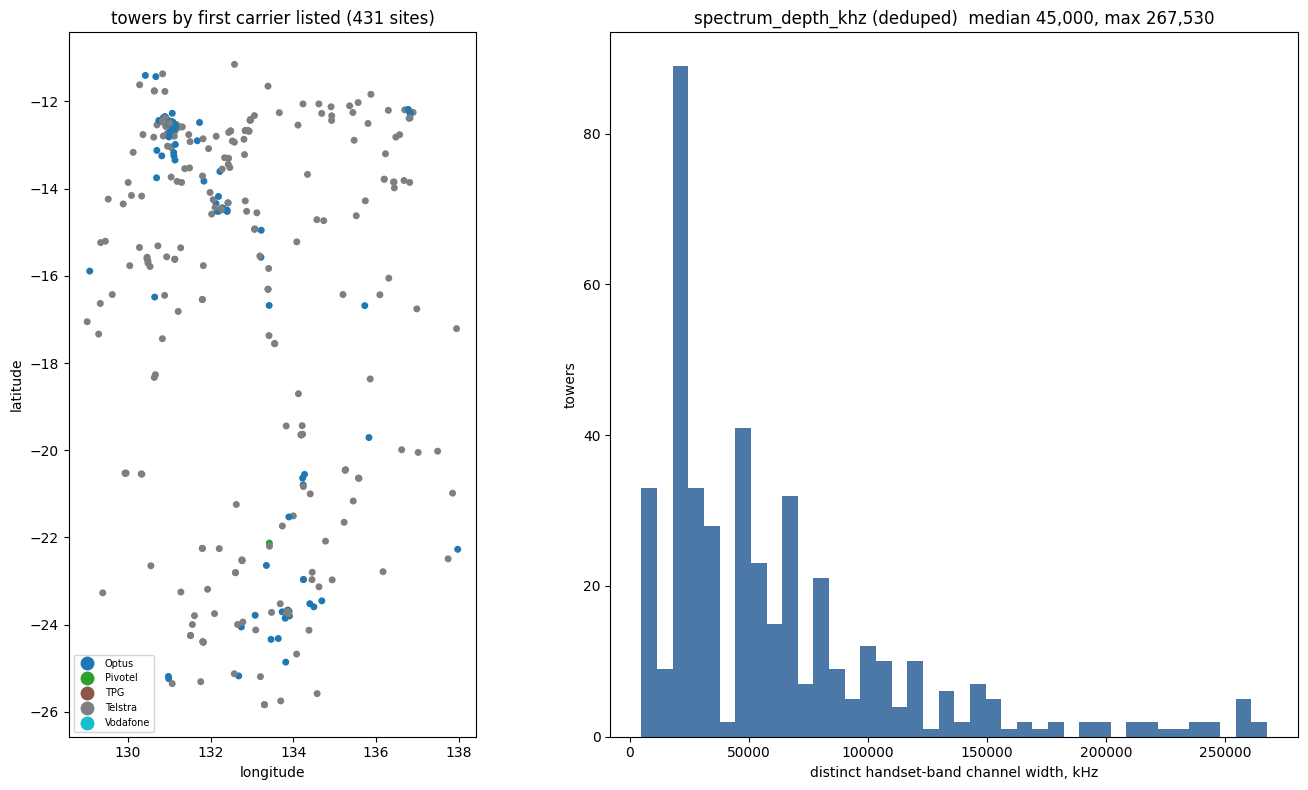

In [14]:
towers_gdf = gpd.GeoDataFrame(
    towers_out_df.copy(),
    geometry=gpd.points_from_xy(towers_out_df["longitude"], towers_out_df["latitude"]),
    crs="EPSG:4326")
towers_gdf["carrier_for_colour"] = towers_gdf["carriers"].str.split(";").str[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
towers_gdf.plot(ax=axes[0], column="carrier_for_colour", cmap="tab10", markersize=16,
                legend=True, legend_kwds={"fontsize": 7, "loc": "lower left"})
axes[0].set_title(f"towers by first carrier listed ({len(towers_gdf)} sites)")
axes[0].set_xlabel("longitude"); axes[0].set_ylabel("latitude")

sd = towers_out_df["spectrum_depth_khz"]
axes[1].hist(sd[sd > 0], bins=40, color="#4c78a8")
axes[1].set_title(f"spectrum_depth_khz (deduped)  median {sd.median():,.0f}, max {sd.max():,.0f}")
axes[1].set_xlabel("distinct handset-band channel width, kHz"); axes[1].set_ylabel("towers")
fig.tight_layout()
eda_figures["03_towers_by_carrier_and_spectrum"] = fig

In [15]:
# Second-to-last cell: summary print.
print("03_towers — summary")
print("-" * 62)
print(f"funnel   : {len(acma_sites_nt_df)} NT sites -> {len(carrier_tx_df)} carrier tx -> "
      f"{len(handset_tx_df)} handset-band carrier tx -> {towers_per_site_df['site_id'].nunique()} sites")
print(f"cluster  : {len(towers_per_site_df)} sites -> {len(towers_out_df)} tower rows "
      f"({int((towers_out_df['n_colocated'] > 1).sum())} rows merge co-located sites)")
print(f"flags    : is_pivotel {int(towers_out_df['is_pivotel'].sum())}, "
      f"is_planning_site {int(towers_out_df['is_planning_site'].sum())} (kept, not dropped — nb 06 decides)")
print(f"old 16-category method (reference) : {len(old_ids)} sites; "
      f"dropped by the switch {len(old_ids - new_ids)}, added {len(new_ids - old_ids)}")
print(f"brands   : " + ", ".join(f"{b} {int(towers_out_df['carriers'].str.contains(b).sum())}"
                                 for b in CARRIER_NAME.values() if towers_out_df['carriers'].str.contains(b).any()))
print(f"networks : " + ", ".join(f"{net} {int(towers_out_df['networks'].str.contains(net).sum())}"
                                 for net in ["Telstra", "Optus", "TPG", "Pivotel", "Dense Air"]
                                 if towers_out_df['networks'].str.contains(net).any()))
print(f"n_networks distribution : {towers_out_df['n_networks'].value_counts().sort_index().to_dict()}")
print(f"spectrum_depth_khz (deduped) : median {towers_out_df['spectrum_depth_khz'].median():,.0f}, "
      f"max {towers_out_df['spectrum_depth_khz'].max():,.0f}")
print("asserts: site_id unique, >=1 carrier & tx, n_networks<=n_carriers, coords in NT box, "
      "columns fixed, deduped spectrum <= raw sum, n_transmitters preserved")

03_towers — summary
--------------------------------------------------------------
funnel   : 3771 NT sites -> 7387 carrier tx -> 5485 handset-band carrier tx -> 461 sites
cluster  : 461 sites -> 431 tower rows (30 rows merge co-located sites)
flags    : is_pivotel 2, is_planning_site 1 (kept, not dropped — nb 06 decides)
old 16-category method (reference) : 458 sites; dropped by the switch 5, added 8
brands   : Telstra 325, Optus 158, Vodafone 52, TPG 70, Pivotel 2
networks : Telstra 325, Optus 158, TPG 76, Pivotel 2
n_networks distribution : {1: 331, 2: 70, 3: 30}
spectrum_depth_khz (deduped) : median 45,000, max 267,530
asserts: site_id unique, >=1 carrier & tx, n_networks<=n_carriers, coords in NT box, columns fixed, deduped spectrum <= raw sum, n_transmitters preserved


In [16]:
# Last cell: every file write.
csv_path     = OUT_DIR / "towers.csv"
geojson_path = OUT_DIR / "towers.geojson"

towers_out_df.to_csv(csv_path, index=False)
gpd.GeoDataFrame(
    towers_out_df.copy(),
    geometry=gpd.points_from_xy(towers_out_df["longitude"], towers_out_df["latitude"]),
    crs="EPSG:4326",
).to_file(geojson_path, driver="GeoJSON")

for name, fig in eda_figures.items():
    fig.savefig(EDA_PLOT_DIR / f"{name}.png", dpi=120, bbox_inches="tight")

print("wrote:")
print(" ", csv_path, f"({len(towers_out_df)} rows)")
print(" ", geojson_path)
for name in eda_figures:
    print("  docs/eda/" + name + ".png")

wrote:
  data\processed\towers.csv (431 rows)
  data\processed\towers.geojson
  docs/eda/03_towers_frequency_bands.png
  docs/eda/03_towers_funnel.png
  docs/eda/03_towers_colocation_clusters.png
  docs/eda/03_towers_by_carrier_and_spectrum.png
